# The Pension Hole — do firms with big underfunded pensions earn *less*? 🕳️
### Off-balance-sheet leverage the market might be ignoring, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Some companies promise their retirees a pension — and set aside a pot of money to pay for it. When that pot is smaller than the promises (the *projected benefit obligation*), the plan is **underfunded**: there's a hole. That hole is a real debt — the company will have to pour cash in to fill it — but it sits in a footnote, not on the main balance sheet. Easy to overlook.

A famous 2006 study (Franzoni & Marin) found that the firms with the **biggest holes** went on to earn the **lowest** stock returns — about 7%/yr worse — as if the market keeps forgetting about the hidden debt until it bites. So we ask: *do big pension holes predict lower returns?*

> ⚠️ **A catch we're upfront about.** The precise pension-hole numbers live in accounting footnotes that **cost money** to get in bulk (Compustat). A free retail data feed doesn't carry them. So we **cannot** test this on real stocks here — instead we build a realistic *synthetic* world where we control the truth, and check that our measuring tools actually work. That's an honest machinery demo, **not** a claim about real markets.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> Not investment advice. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pension_underfunding import data, strategy as st

# The real point-in-time pension-footnote panel is NOT free (see data.py) -> synthetic-only.
REAL = data.real_panel(fetch=False)
HAVE_REAL = not REAL.empty
print("real pension panel present:", HAVE_REAL, "-> synthetic-only study (data caveat on SIGNAL axis)")

# The DETERMINISTIC synthetic world is the tape we test on (seed 571, planted alpha = -0.05).
PANEL, TRUTH = data.synthetic_panel()
print(f"synthetic panel: {len(PANEL)} firms, planted underfunding_alpha={TRUTH.underfunding_alpha}, "
      f"fp={data.fingerprint(PANEL)}")


real pension panel present: False -> synthetic-only study (data caveat on SIGNAL axis)
synthetic panel: 300 firms, planted underfunding_alpha=-0.05, fp=b43234ffbd01


## The answer first 🎯

| Question | Answer |
|---|---|
| Is the pension-hole effect real in the literature? | **Yes** — Franzoni-Marin (2006) document it: biggest holes → ~7%/yr *lower* returns. |
| Can we prove it on real stocks here? | **No** — the pension-footnote data isn't free. So the Signal stamp is **None** (not evidenced on a real tape), by honest necessity. |
| Does our engine at least *work*? | **Yes** — on a synthetic world with a planted hole-effect it cleanly finds it (the well-funded firms beat the underfunded ones by **+8.79%**), and finds *nothing* when there's nothing to find. |
| Could you trade it? | **No** — you'd short stressed, hard-to-borrow firms, and you can't even build the signal without paying for the data. |

> The short version: a real anomaly the free retail stack simply **cannot reach**. We show the tool is sharp; we just don't have the tape to point it at.

## 1 · The claim

> *"The most underfunded pension firms earn anomalously low returns."* — the pension-underfunding anomaly (Franzoni & Marin 2006).

Why it's a *puzzle*: a big pension hole is like hidden debt. More debt should mean more risk and — in theory — higher expected returns to compensate. Instead the data says the opposite: the most-underfunded firms *underperform*. The story is that the hole is buried in a footnote and slowly smoothed by pension accounting, so investors **under-react** — they don't mark the stock down enough, and it drifts lower as the truth leaks out through cash contributions and earnings hits.

## 2 · So what?

If true, it says the market is *inefficient* about a specific, knowable accounting item — a footnote everyone could read but few fully price. And it suggests a trade: **own the well-funded firms, avoid (or short) the underfunded ones.** The desk has looked at the *on*-balance-sheet [154 Leverage-Anomaly](../../154-leverage-anomaly/); this is its sneaky *off*-balance-sheet cousin — leverage hiding in the pension footnote.

## 3 · How would we even know?

1. **Measure the hole.** For each firm: (plan assets − pension promises) ÷ company value. Negative = underfunded. The more negative, the deeper the hole.
2. **Sort.** Rank firms by hole depth; take the *well-funded* fifth and the *most-underfunded* fifth.
3. **Compare forward returns.** Did the well-funded fifth beat the underfunded fifth over the next year? The puzzle says yes.

**The honest catch:** step 1 needs the pension footnote, which isn't in any free feed. So we build a *synthetic* world where we know the true hole for 300 firms and can dial the effect on and off — then check our sorter finds it when it's there and stays quiet when it isn't.

*Timing:* the hole is read from the last published report; we enter **after** it's public and hold forward. No peeking.

## 4 · The teardown — the synthetic world

**In a world where the pension-hole effect is real, do the well-funded firms win?** (This is our synthetic tape — the truth is planted, so we *should* see it.)

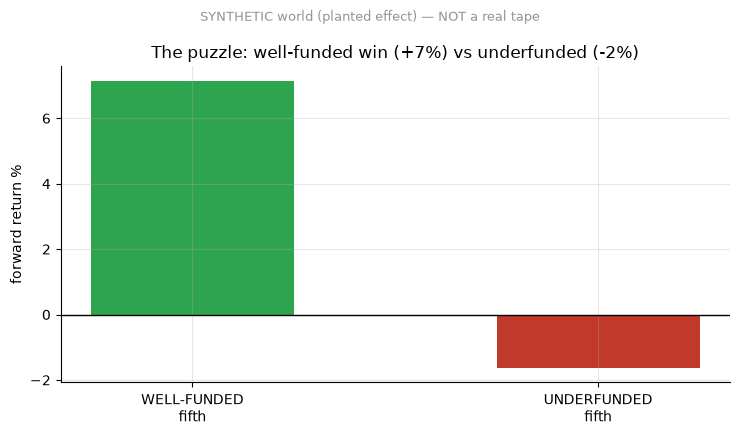

Well-funded +7.1%  vs  Underfunded -1.6%  ->  spread +8.8% (t +2.45)


In [2]:
b = st.bucket_returns(PANEL, frac=0.2); ls = st.long_short_tstat(b)
well_m, under_m, spr, t = b['well_mean']*100, b['under_mean']*100, b['spread']*100, ls['t']
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['WELL-FUNDED\nfifth','UNDERFUNDED\nfifth'], [well_m, under_m], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'The puzzle: well-funded win (+{well_m:.0f}%) vs underfunded ({under_m:+.0f}%)')
fig.suptitle('SYNTHETIC world (planted effect) — NOT a real tape', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'Well-funded +{well_m:.1f}%  vs  Underfunded {under_m:+.1f}%  ->  spread {spr:+.1f}% (t {t:+.2f})')

There's the puzzle, the right way round: the well-funded fifth earned **+7.15%** and the deeply-underfunded fifth **-1.64%** — a **+8.79%** gap (*t* 2.45). Our sorter finds the planted effect. Good — the tool works. **Remember: this is the synthetic world, not real stocks.**

**And when there's *no* effect to find, does the tool stay quiet?** Turn the knob to zero (no pension-hole effect) and re-sort:

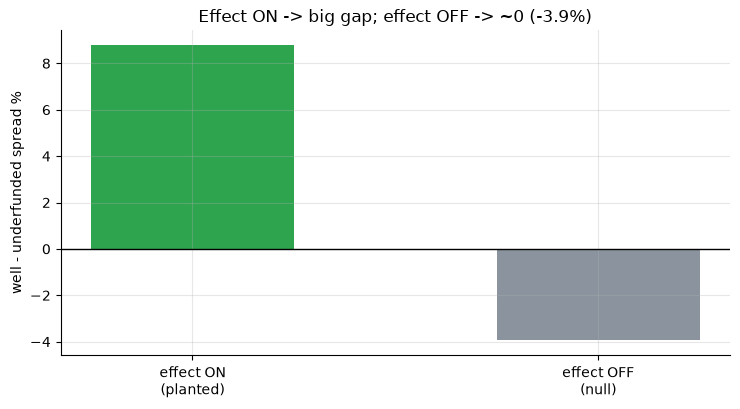

null-world spread -3.94% (t -1.12) — flat, as it should be


In [3]:
null_panel, _ = data.synthetic_panel(underfunding_alpha=0.0)
bn = st.bucket_returns(null_panel, 0.2); lsn = st.long_short_tstat(bn)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['effect ON\n(planted)','effect OFF\n(null)'],
       [st.bucket_returns(PANEL,0.2)['spread']*100, bn['spread']*100],
       color=[GREEN, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('well - underfunded spread %')
ax.set_title(f'Effect ON -> big gap; effect OFF -> ~0 ({bn["spread"]*100:+.1f}%)')
plt.tight_layout(); plt.show()
print(f'null-world spread {bn["spread"]*100:+.2f}% (t {lsn["t"]:+.2f}) — flat, as it should be')

With the effect switched off the gap collapses to roughly zero — the tool doesn't invent a signal out of noise. So the engine is honest in **both** directions.

## 5 · The verdict

- **Signal — None.** Not because the anomaly is fake (the literature says it's real), but because **we have no real tape** — the pension-footnote data isn't free, and the desk only awards a real signal for a robust result on *real* data.
- **Tradability — Mirage.** The short leg is stressed, hard-to-borrow firms, and you can't even source the signal cheaply.

## 6 · Could you actually trade it?

No — twice over. First, to *build* the signal you'd need to pay for the pension-footnote data. Second, the trade means *shorting* the most-underfunded firms — often stressed, old-economy names that are expensive and hard to borrow. Even in our synthetic world, where the effect exists, a 150 bps borrow trims the **+8.79%** gross gap to **+7.09%** net.

## 7 · Going further 🚪

- **The on-balance-sheet cousin.** [154 Leverage-Anomaly](../../154-leverage-anomaly/) tests *visible* debt; this is the *hidden*, pension kind.
- **The under-reaction family.** [231 Sloan-Accruals](../../231-sloan-accruals/) — the market under-reacting to another opaque accounting item.
- **The real test needs the footnotes.** With Compustat pension items (PBO, plan assets, funded status) you could run the true Franzoni-Marin sort on a real, survivorship-free panel — that's where the anomaly earns its keep.

*Have the pension-footnote data? Fork this, drop in a real point-in-time funded-status panel, and show the well-minus-underfunded spread clearing t = 2 on the tape.*